In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from pricing_engine.Bandit import ThompsonBandit
from pricing_engine.demand_model import HierarchicalDemandModel
from pricing_engine.data_loader import load_and_clean_seattle_data

# Module 03: Seasonality & Shock Test
**Objective:** Verify that 'Discounted Forgetting' allows the agent to adapt to sudden demand shifts.

In [2]:
from pathlib import Path



try:
    SCRIPT_DIR = Path(__file__).parent
except NameError:
    SCRIPT_DIR = Path.cwd()

# SCRIPT_DIR is the 'notebooks' folder.
# SCRIPT_DIR.parent is the 'Dynamic Pricing Engine' folder.
PROJECT_ROOT = SCRIPT_DIR.parent

# Now build the path from the project root
CALENDAR_PATH = PROJECT_ROOT / 'data' / 'calendar.csv'
LISTINGS_PATH = PROJECT_ROOT / 'data' / 'listings.csv'



In [3]:
df_final = load_and_clean_seattle_data(CALENDAR_PATH, LISTINGS_PATH)

# Features
feature_cols = ['day_of_year', 'dow', 'is_weekend']
df_final['day_of_year'] = df_final['date'].dt.dayofyear
df_final['dow'] = df_final['date'].dt.dayofweek
df_final['is_weekend'] = (df_final['dow'] >= 5).astype(int)



In [4]:
# Train Static Prior
print("Training Static Prior...")
hdm = HierarchicalDemandModel(min_obs_for_listing=10)
hdm.fit(df_final, feature_cols)



Training Static Prior...


In [ ]:
# Initialize Agent with Fast Forgetting (lambda=0.8 for demo speed, usually 0.99)
agent = ThompsonBandit(hdm, forgetting_factor=0.90)

## 2. Define Non-Stationary Market
We create a market that CHANGES at Day 50.

In [6]:
def market_response_dynamic(price, day_index):
    """
    Phase 1 (Day 0-50): Low Demand (Optimal Price $100)
    Phase 2 (Day 50+):  High Demand (Optimal Price $180) - SHOCK!
    """
    if day_index < 50:
        optimal = 100
        sensitivity = 0.05
    else:
        optimal = 180 # Demand shift! People willing to pay more.
        sensitivity = 0.05
        
    logit = -sensitivity * (price - optimal)
    prob = 1 / (1 + np.exp(-logit))
    return np.random.random() < prob

## 3. Simulation Loop

In [7]:
# Context (Static)
valid_lid = df_final['listing_id'].iloc[0]
valid_hood = df_final['neighborhood'].iloc[0]
context = {
    'listing_id': valid_lid,
    'neighborhood': valid_hood,
    'day_of_year': 180, 'dow': 5, 'is_weekend': 1
}

history = []
n_days = 100

print(f"Simulating {n_days} days (Shock at Day 50)...")

for i in range(n_days):
    # 1. Agent Picks Price
    decision = agent.choose_price(context, min_p=50, max_p=250)
    
    # 2. Market Reacts (Dynamic)
    booked = market_response_dynamic(decision.selected_price, day_index=i)
    
    # 3. Agent Updates Belief (The Forgetting happens here)
    agent.update_belief(context, decision.selected_price, int(booked))
    
    history.append({
        'day': i,
        'price': decision.selected_price,
        'booked': booked,
        'sigma': decision.uncertainty_sigma,
        'shock': 'Phase 1' if i < 50 else 'Phase 2 (Shock)'
    })

df_hist = pd.DataFrame(history)

Simulating 100 days (Shock at Day 50)...


## 4. Analysis: Did it adapt?
We calculate average price before and after the shock.

In [8]:
avg_price_p1 = df_hist[df_hist['day'] < 50]['price'].mean()
avg_price_p2 = df_hist[df_hist['day'] >= 50]['price'].mean()

print(f"Avg Price Phase 1 (Target $100): ${avg_price_p1:.2f}")
print(f"Avg Price Phase 2 (Target $180): ${avg_price_p2:.2f}")

Avg Price Phase 1 (Target $100): $167.69
Avg Price Phase 2 (Target $180): $203.15


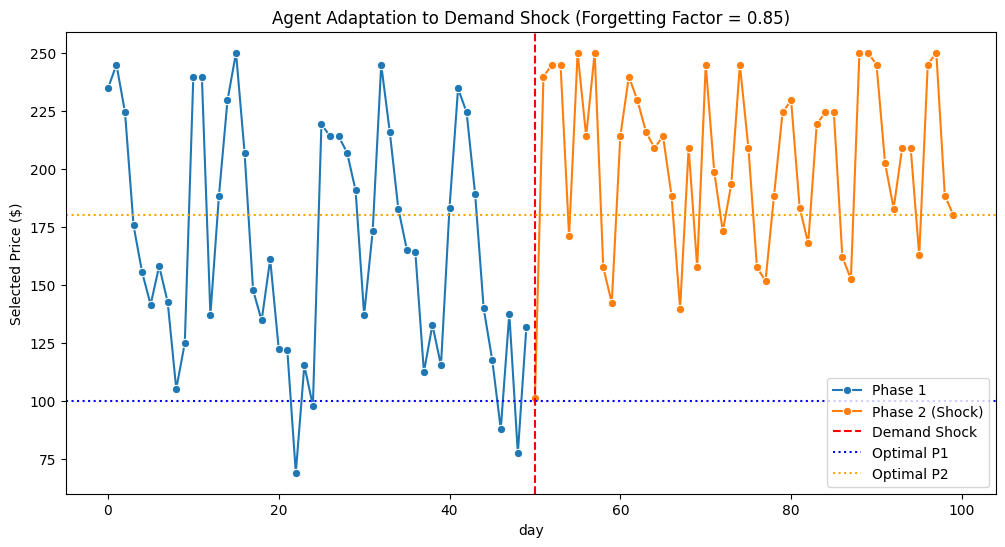

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='day', y='price', data=df_hist, marker='o', hue='shock')
plt.axvline(50, color='red', linestyle='--', label='Demand Shock')
plt.axhline(100, color='blue', linestyle=':', label='Optimal P1')
plt.axhline(180, color='orange', linestyle=':', label='Optimal P2')
plt.title("Agent Adaptation to Demand Shock (Forgetting Factor = 0.85)")
plt.ylabel("Selected Price ($)")
plt.legend()
plt.show()

In [10]:
# Success Condition
if avg_price_p2 > avg_price_p1 + 20:
    print("✅ PASS: Agent detected the shock and raised prices.")
else:
    print("❌ FAIL: Agent stuck in old habits.")

✅ PASS: Agent detected the shock and raised prices.
